# MCTS sweep — results explorer

Everything here is built from the **`charts`** module (generic, column-name charts) + a few
lines of matplotlib where `charts` has no primitive. Three modules do the work: **`dataset`**
(build/load the parquet), **`charts`**, and **`schema`** (documents every column).

* **Part 1** rebuilds the polished *deck* figures (`plots.py`) using only `charts`.
* **Part 2** compares the two **objectives** — `peak` (the best frame the plan passes
  through) vs `last` (the state it *ends on*). Every tree carries both.
* **Part 3** asks how reliable a config is: paired-across-inits deltas and planner-seed
  replicates (`n_seeds`).
* **Part 4** compares two runs (e.g. the Gaussian- vs uniform-prior sweeps).
* **Part 5** puts the outcome against the **compute budget** each config actually spends.
* **Part 6** turns it around and makes a **tree property** the subject — which knobs shape
  it, and whether it discriminates successful from failed trees well enough to serve as an
  online monitor.
* **Part 7** keeps the per-link / correlation views.

Point the loader below at any run's shard directory.

## Setup

`load_run` below is cache-aware: it reads `<run>/analysis/trees.parquet` if it exists and
otherwise builds it from the shards and writes the cache, so the first run of a fresh sweep
costs one CSV concat and every later one is instant. Pass `rebuild=True` after new sweep
rows land.

In [1]:
from dreamerv4uwm.planning.experiments.study.analysis import dataset, charts, schema
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
%matplotlib inline
pd.set_option("display.width", 170)

# A run is a directory of shard_*.csv, cached as one parquet. `dataset.build` concatenates
# the shards, dedups on (config_id, init_id, plan_seed) and adds the success_<outcome>
# flags; `dataset.load` reads the cache back.
#
# Same thing from the shell (either line writes the parquet this notebook then loads):
#   python -m ...analysis.dataset --input-dir <run> --out <run>/analysis/trees.parquet
#   python -m ...analysis.report  --input-dir <run> --out-dir <run>/analysis   # + figures

def load_run(run, rebuild=False):
    """Cached loader: read <run>/analysis/trees.parquet if present, else build it from
    the shards AND write the cache. `rebuild=True` forces a re-read of the shards, which
    is what you want after a sweep task appends new rows."""
    pq = Path(run) / "analysis" / "trees.parquet"
    if pq.exists() and not rebuild:
        return dataset.load(pq)
    return dataset.build(run, out=pq)

RUN = "mcts_sweep/run_normal"
df  = load_run(RUN)

In [2]:
# --- the objective switch ---------------------------------------------------
# Every row carries BOTH objectives (see baselines.py):
#   peak — best reward over ANY frame of the trajectory (MPC-style, matches the tree's
#          best-prefix back-up);
#   last — reward of the FINAL state only ("where did you end up"), the right objective
#          when the task is to reach AND HOLD a configuration.
# A plan that shoves the T across the centre and out again scores well on peak and badly
# on last. They are never mixed: each gain is only meaningful against its own tree_* .
# Set OBJ once — every cell below follows it.
OBJ   = "last"                       # "peak" | "last"

GAIN  = f"g_random_{OBJ}"            # vs ONE undirected rollout at the plan's lookahead
GAIN2 = f"g_greedy_{OBJ}"            # vs best-of-N random shooting  (the harder test)
ABS   = f"tree_{OBJ}"                # the absolute reward the plan achieved
OUT   = GAIN                         # the headline outcome most cells plot

print(dataset.overview(df, OUT))

2880 trees  |  72 configs  |  40 inits
g_random_last success rate: 65.5%
mostly-NaN columns: val_std_depth3


In [3]:
KNOBS = [k for k in schema.FACTORS if k in df.columns and df[k].nunique(dropna=True) > 1]
METS  = charts.metric_cols(df)
print(f"objective = {OBJ}  ->  gains {GAIN} / {GAIN2}, absolute {ABS}")
print(f"{len(KNOBS)} swept knobs: {KNOBS}")
print(f"{len(METS)} candidate predictor metrics")

# What this run actually is — recorded per row, so never assumed:
for c in ("reward_kind", "descriptor_kind", "edge_mode"):
    if c in df.columns:
        print(f"  {c:16s} {sorted(df[c].unique())}")

# Config-tag families. `charts.ofat` slices Tier-1 only (base + ofat.<knob>=v); the
# Tier-2 `rand.i` samples and any `bo.rN.i` rounds from optimize.py are EXCLUDED from
# the response curves (they'd dilute a one-factor curve) but are still in every
# scatter / correlation / distribution below.
fam = df.config_tag.str.extract(r"^(base|ofat|rand|bo)")[0].fillna("other")
print("  config families:", fam.value_counts().to_dict())
print("  replicates per (config, init):",
      df.groupby(["config_id", "init_id"]).size().value_counts().to_dict())

objective = last  ->  gains g_random_last / g_greedy_last, absolute tree_last
10 swept knobs: ['ctx_noise', 'horizon', 'sim_horizon', 'branching', 'action_temp', 'action_prior', 'state_prior', 'c_ucb', 'max_depth', 'n_iterations']
50 candidate predictor metrics
  reward_kind      ['angle']
  descriptor_kind  ['heading']
  edge_mode        ['imagine']
  config families: {'rand': 2000, 'ofat': 840, 'base': 40}
  replicates per (config, init): {1: 2880}


In [4]:
# Three small helpers `charts` doesn't have (a few lines of matplotlib, per its philosophy).

def effect_size(knob, y=None):
    """max - min of the mean outcome across a knob's OFAT settings."""
    y = y or OUT
    g = charts.ofat(df, knob).groupby(knob, observed=True)[y].mean()
    return float(np.nanmax(g) - np.nanmin(g)) if g.notna().sum() > 1 else 0.0


def binned_rate(x, y=None, q=6, data=None):
    """Success rate within quantile bins of metric `x`. 'Success' is the `success_<y>`
    flag dataset.build already added: gain > 0, or tree_* >= schema.PEAK_THRESHOLD --- so
    this stays correct when you flip OBJ or point y at an absolute outcome."""
    y = y or OUT
    d = (df if data is None else data)
    s = f"success_{y}"
    d = d[[x, s]].replace([np.inf, -np.inf], np.nan).dropna()
    d = d.assign(_b=pd.qcut(d[x], q, duplicates="drop"))
    g = d.groupby("_b", observed=True)
    return g[x].mean().to_numpy(), g[s].mean().to_numpy()


def knob_grid(y, data=None, ncol=3, title=None):
    """One OFAT response curve per swept knob. `y` is a column or a list of columns."""
    d  = df if data is None else data
    ks = [k for k in KNOBS if k in d.columns]
    nrow = int(np.ceil(len(ks) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.6 * ncol, 3.2 * nrow), squeeze=False)
    for ax, k in zip(axes.ravel(), ks):
        charts.response(charts.ofat(d, k), k, y, ax=ax)
        ax.set_title(k, fontsize=10)
    for ax in axes.ravel()[len(ks):]:
        ax.axis("off")
    lab = y if isinstance(y, str) else " / ".join(y)
    fig.suptitle(title or f"{lab} vs each knob (one-factor-at-a-time)", y=1.0)
    fig.tight_layout()
    return fig

## Part 1 — the deck, rebuilt from `charts`

### 1a. The headline (`fig_ctxnoise`): diversity rises, but usefulness peaks then cliffs
`charts.response` on the OFAT slice of `ctx_noise` — branch-collapse (diversity) on the left,
both planning gains on the right.

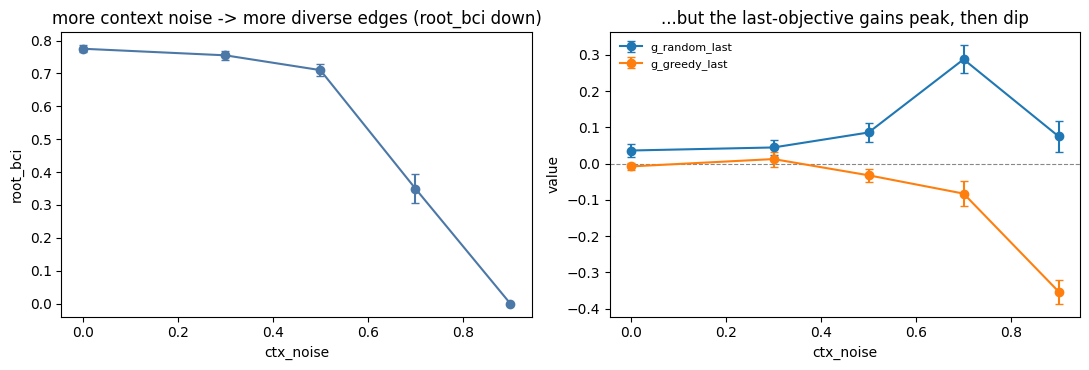

In [5]:
sl = charts.ofat(df, "ctx_noise")
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
charts.response(sl, "ctx_noise", "root_bci", ax=ax[0])
charts.response(sl, "ctx_noise", [GAIN, GAIN2], ax=ax[1])
ax[0].set_title("more context noise -> more diverse edges (root_bci down)")
ax[1].set_title(f"...but the {OBJ}-objective gains peak, then dip")
fig.tight_layout()

### 1b. Which knobs move planning (`fig_knob_curves`) — one response curve per knob

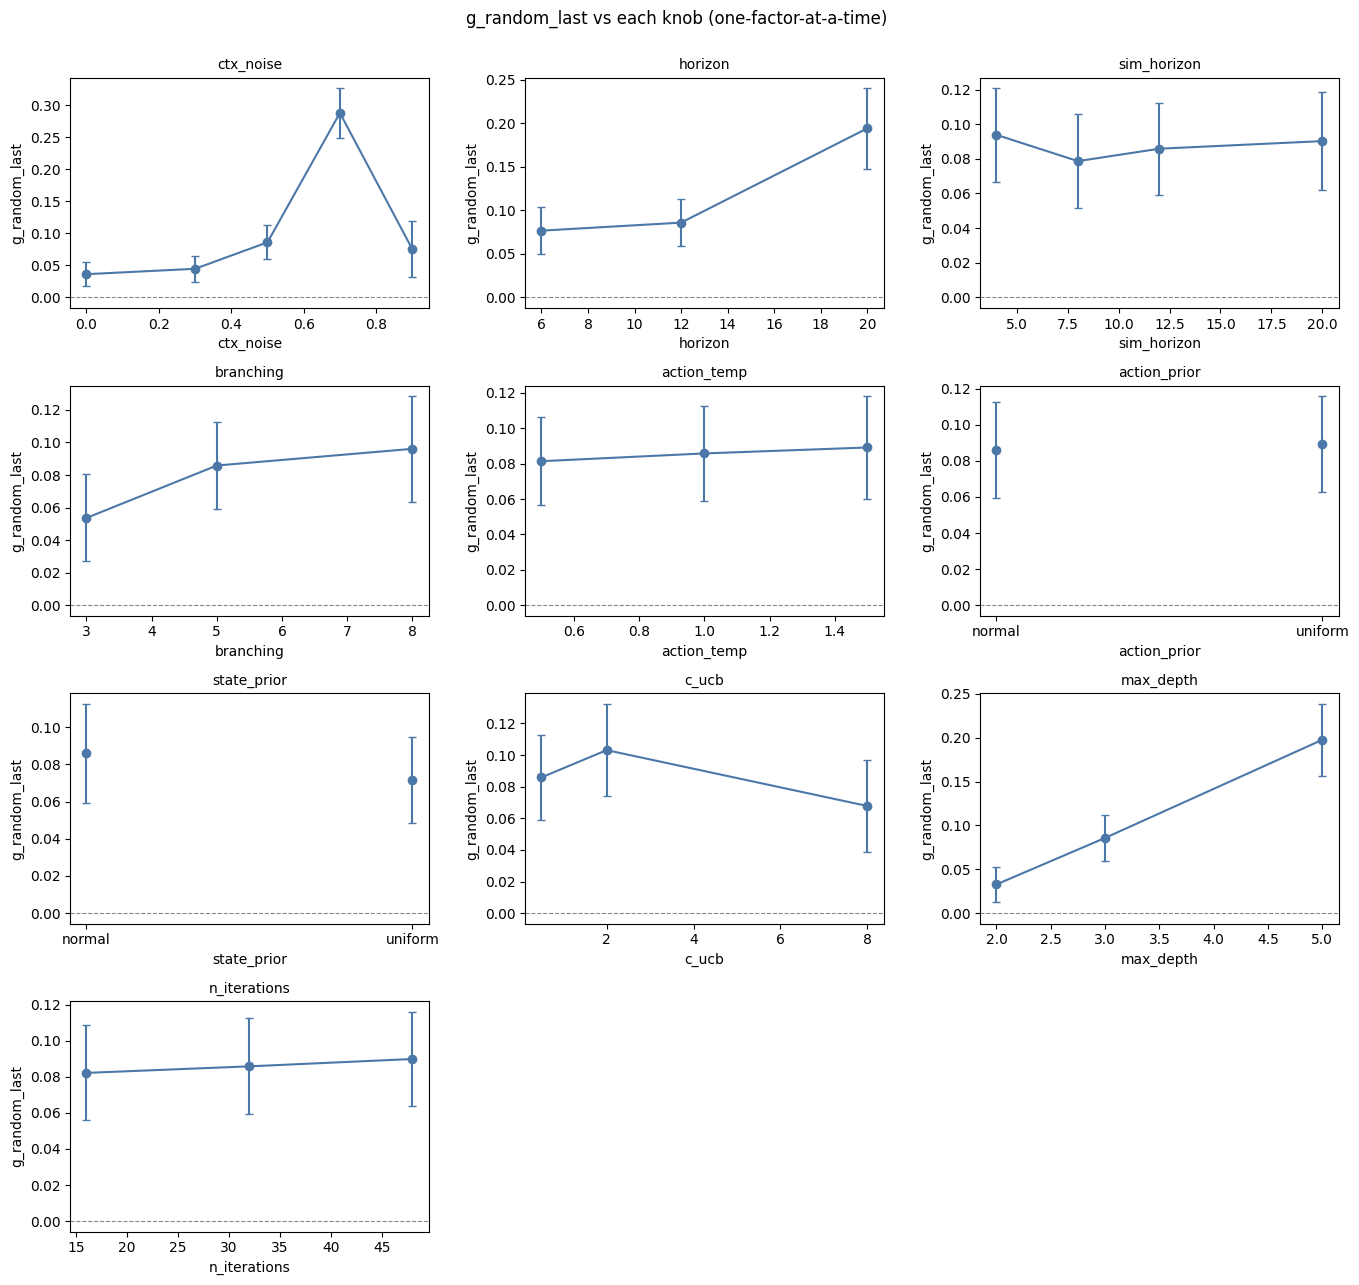

In [6]:
knob_grid(OUT);

### 1b'. …and the effect-size bar (`fig_knob_effects`): max−min mean gain per knob

Shown for **both** objectives: a knob that moves `peak` but not `last` improves the best
moment the plan passes through without improving where it ends up.

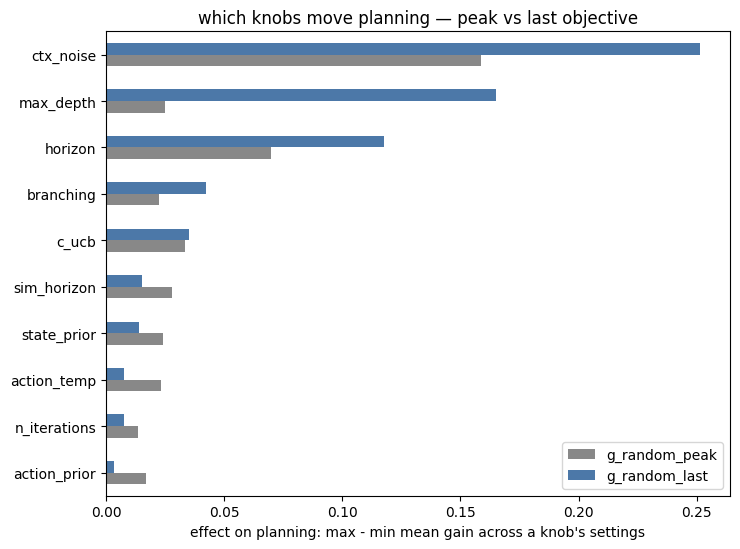

In [7]:
effs = [o for o in ("g_random_peak", "g_random_last") if o in df.columns]
eff  = pd.DataFrame({o: {k: effect_size(k, o) for k in KNOBS} for o in effs})
eff  = eff.sort_values(effs[-1])
ax = eff.plot.barh(figsize=(7.5, 0.42 * len(eff) + 1.4), color=[charts.GREY, charts.BLUE][:len(effs)])
ax.set_xlabel("effect on planning: max - min mean gain across a knob's settings")
ax.set_title("which knobs move planning — peak vs last objective")
ax.figure.tight_layout()

### 1b''. All outcomes of the current objective, per knob

`tree_*` is *absolute* reward (0–1) while `g_random`/`g_greedy` are *relative* to the
baselines (~0), so on one axis you see both: where `tree_*` moves but the gains stay flat,
the knob improves the reached state without beating the baselines — and where the gains
move, search is actually paying off.

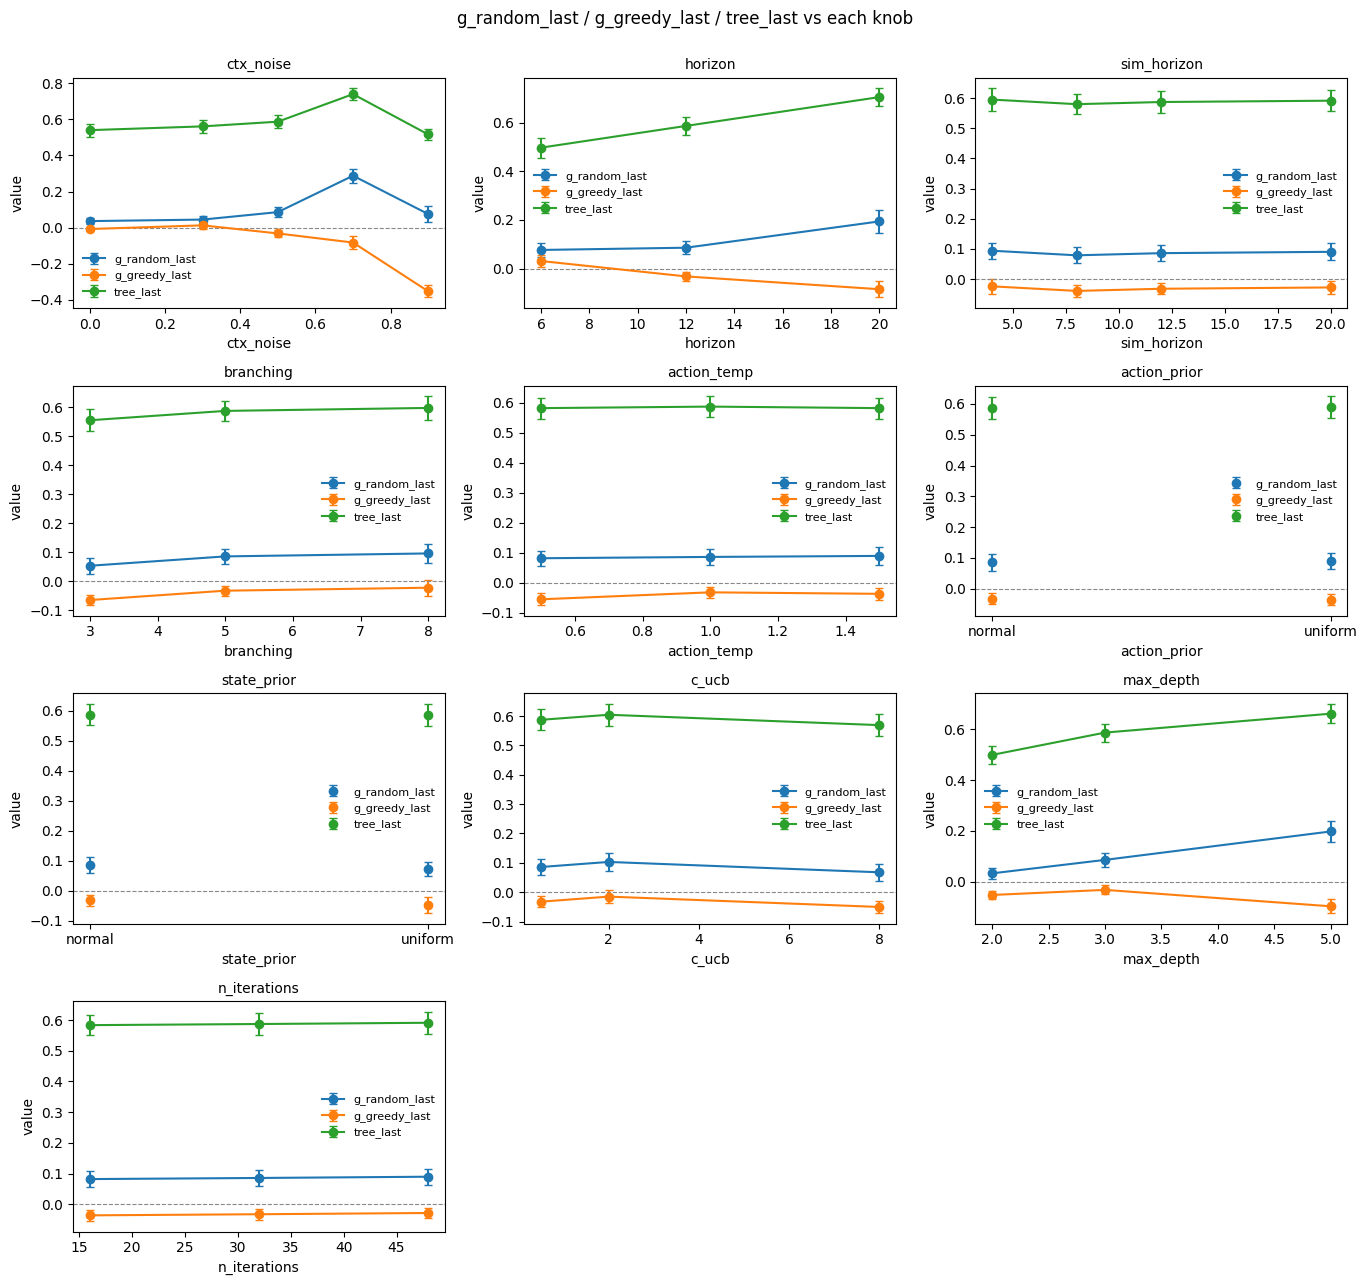

In [8]:
knob_grid([GAIN, GAIN2, ABS], title=f"{GAIN} / {GAIN2} / {ABS} vs each knob");

### 1c. What predicts a good tree (`fig_predictors`) — per-tree Spearman with the outcome

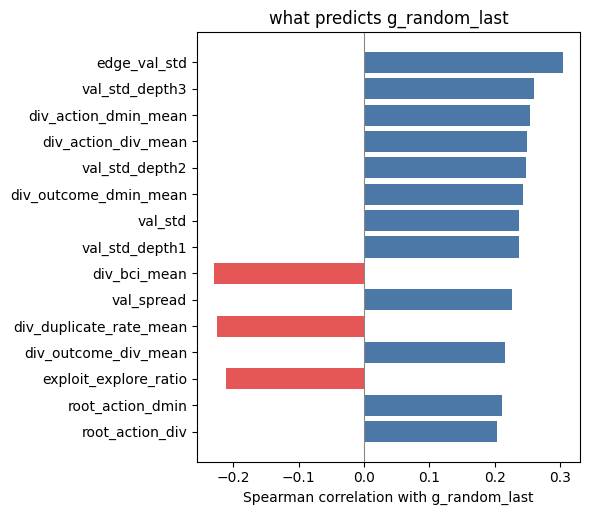

In [9]:
charts.corr_bars(df, OUT, top=15);

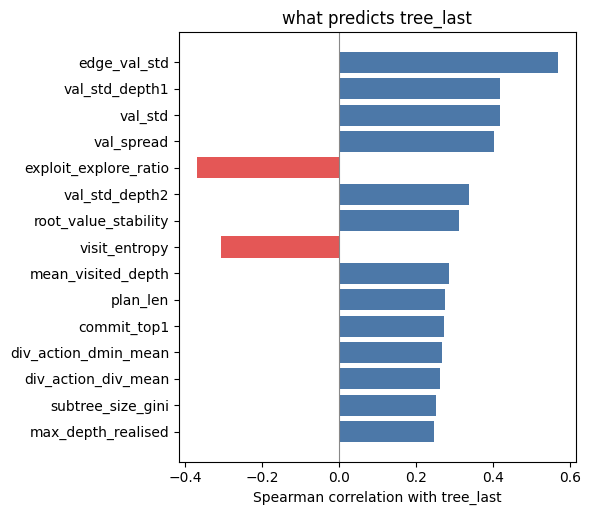

In [10]:
charts.corr_bars(df, ABS, top=15);

### 1d. The mechanism (`fig_mechanism`): edge-reward diversity → planning gain
Left: one dot per tree (coloured by `ctx_noise`). Right: success rate binned by the same metric.

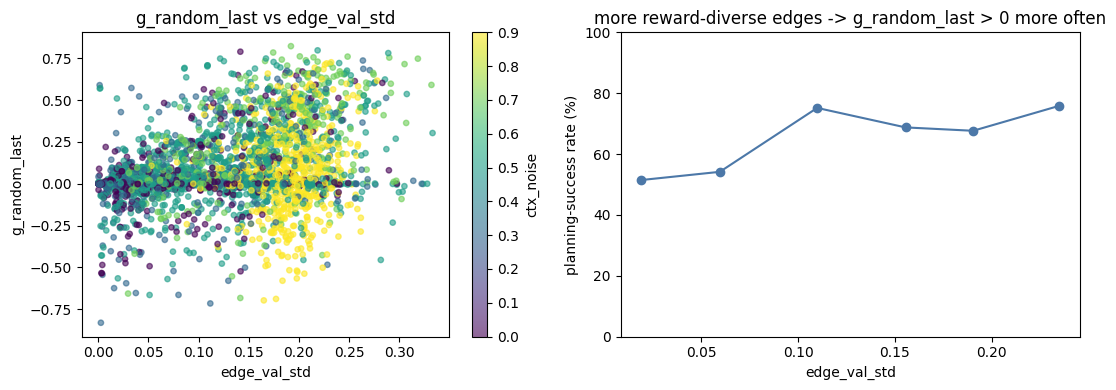

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
charts.scatter(df, "edge_val_std", OUT, color="ctx_noise", ax=ax[0])
x, rate = binned_rate("edge_val_std")
ax[1].plot(x, 100 * rate, "o-", color=charts.BLUE)
ax[1].set(xlabel="edge_val_std", ylabel="planning-success rate (%)",
          title=f"more reward-diverse edges -> {OUT} > 0 more often")
ax[1].set_ylim(0, 100)
fig.tight_layout()

## Part 2 — peak vs last: the two objectives

`baselines.py` runs each control ONCE and reads it out twice, so the terminal-objective
numbers are free and every tree has all six outcomes. The comparison matters because they
can disagree: `peak` rewards the best moment anywhere in the trajectory (an MPC controller
re-planning every step would get it), `last` rewards the state actually reached at the end
(what you get if you execute the whole plan open-loop).

**Always compare like with like** — `g_*_last` is `tree_last` minus a `*_last` baseline,
never `tree_peak`.

### 2a. Where the six outcomes land

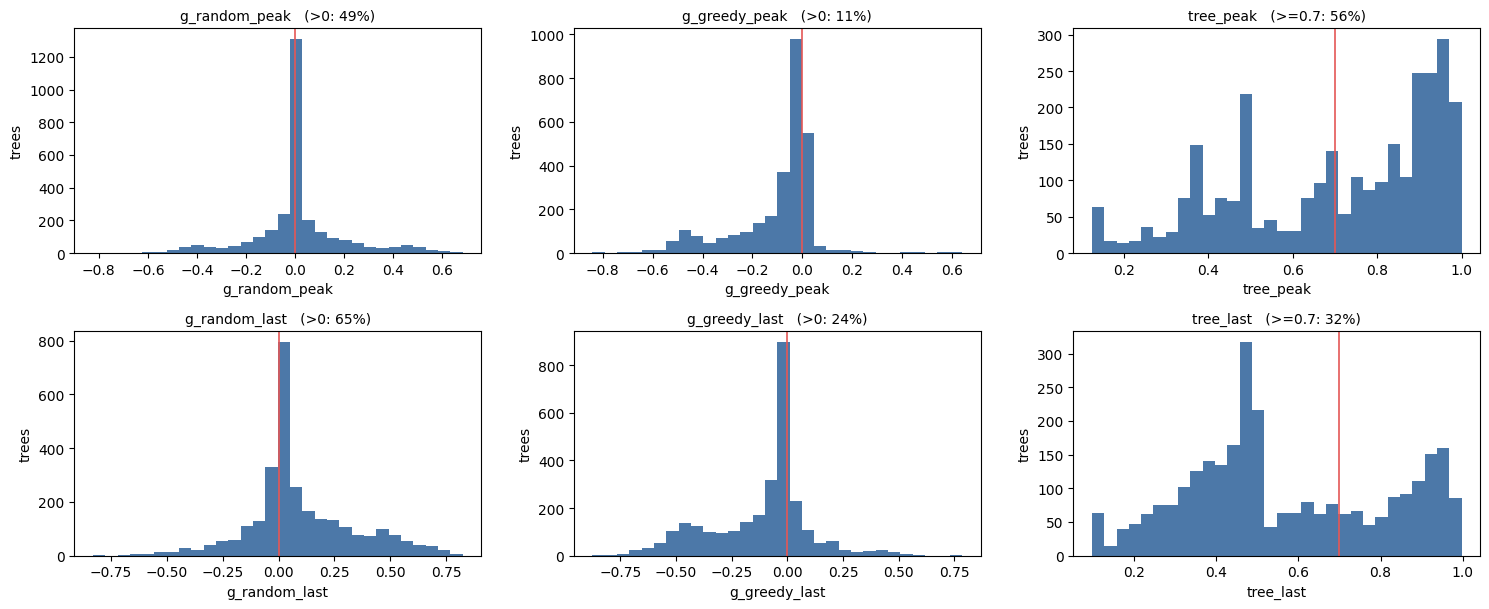

In [12]:
cols = [c for c in ["g_random_peak", "g_greedy_peak", "tree_peak",
                    "g_random_last", "g_greedy_last", "tree_last"] if c in df.columns]
fig, axes = plt.subplots(2, 3, figsize=(15, 6.2))
for ax, c in zip(axes.ravel(), cols):
    charts.hist(df, c, ax=ax)
    if c.startswith("g_"):                    # 0 = "no better than the matched baseline"
        ax.axvline(0, color=charts.RED, lw=1.2)
        ax.set_title(f"{c}   (>0: {(df[c] > 0).mean():.0%})", fontsize=10)
    else:                                     # absolute reward: the task-success threshold
        thr = schema.PEAK_THRESHOLD
        ax.axvline(thr, color=charts.RED, lw=1.2)
        ax.set_title(f"{c}   (>={thr}: {(df[c] >= thr).mean():.0%})", fontsize=10)
for ax in axes.ravel()[len(cols):]:
    ax.axis("off")
fig.tight_layout()

### 2b. The same thing as a table

`g_random_*` asks *did planning beat acting on the prior once?*; `g_greedy_*` asks the
harder *was the **search** worth it over best-of-N shooting at the same lookahead?*

In [13]:
rows = []
for o in ["g_random_peak", "g_greedy_peak", "g_random_last", "g_greedy_last"]:
    if o in df.columns:
        rows.append({"outcome": o, "mean": df[o].mean(), "sem": df[o].sem(),
                     "median": df[o].median(), "success_rate": df[f"success_{o}"].mean()})
pd.DataFrame(rows).set_index("outcome").round(4)

,mean,sem,median,success_rate
outcome,,,,
g_random_peak,0.0091,0.0035,-0.0001,0.4899
g_greedy_peak,-0.1007,0.0031,-0.0304,0.1125
g_random_last,0.0942,0.0044,0.0274,0.6549
g_greedy_last,-0.1143,0.0042,-0.0429,0.2382


### 2c. How much of the peak survives to the end?

Below the diagonal = the plan passed through a good state and then left it. The gap is
exactly what the `last` objective penalises and the `peak` one does not.

mean drop (tree_peak - tree_last) = 0.1332   median = 0.0442
trees ending within 0.05 of their peak: 51.6%


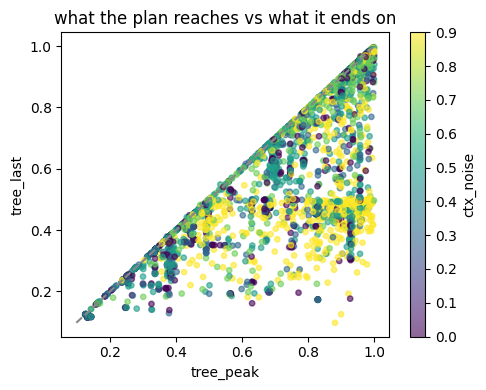

In [14]:
ax = charts.scatter(df, "tree_peak", "tree_last", color="ctx_noise")
lim = [min(df.tree_peak.min(), df.tree_last.min()), max(df.tree_peak.max(), df.tree_last.max())]
ax.plot(lim, lim, ls="--", color=charts.GREY)
ax.set_title("what the plan reaches vs what it ends on")
drop = df.tree_peak - df.tree_last
print(f"mean drop (tree_peak - tree_last) = {drop.mean():.4f}   median = {drop.median():.4f}")
print(f"trees ending within 0.05 of their peak: {(drop <= 0.05).mean():.1%}")

### 2d. Does a knob help both objectives, or only one?

Two grids: the gain over a single rollout, then the gain over best-of-N shooting, each with
the peak and last readouts on the same axis.

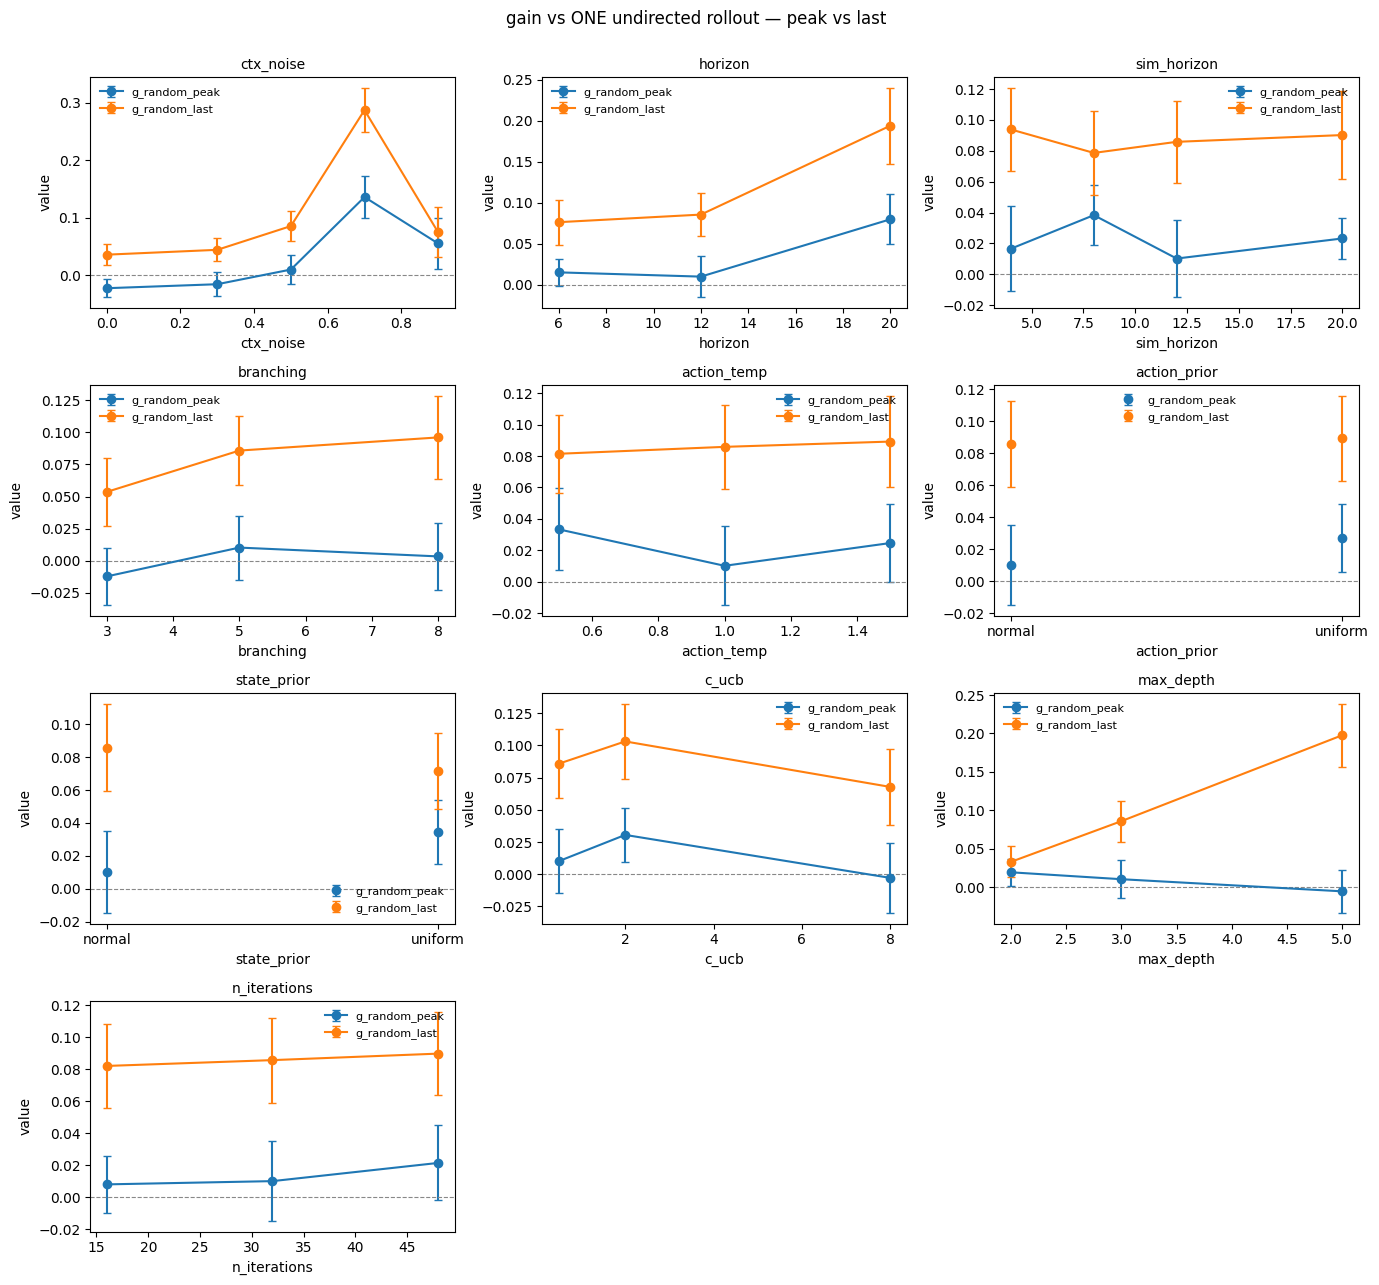

In [15]:
knob_grid([c for c in ["g_random_peak", "g_random_last"] if c in df.columns],
          title="gain vs ONE undirected rollout — peak vs last");

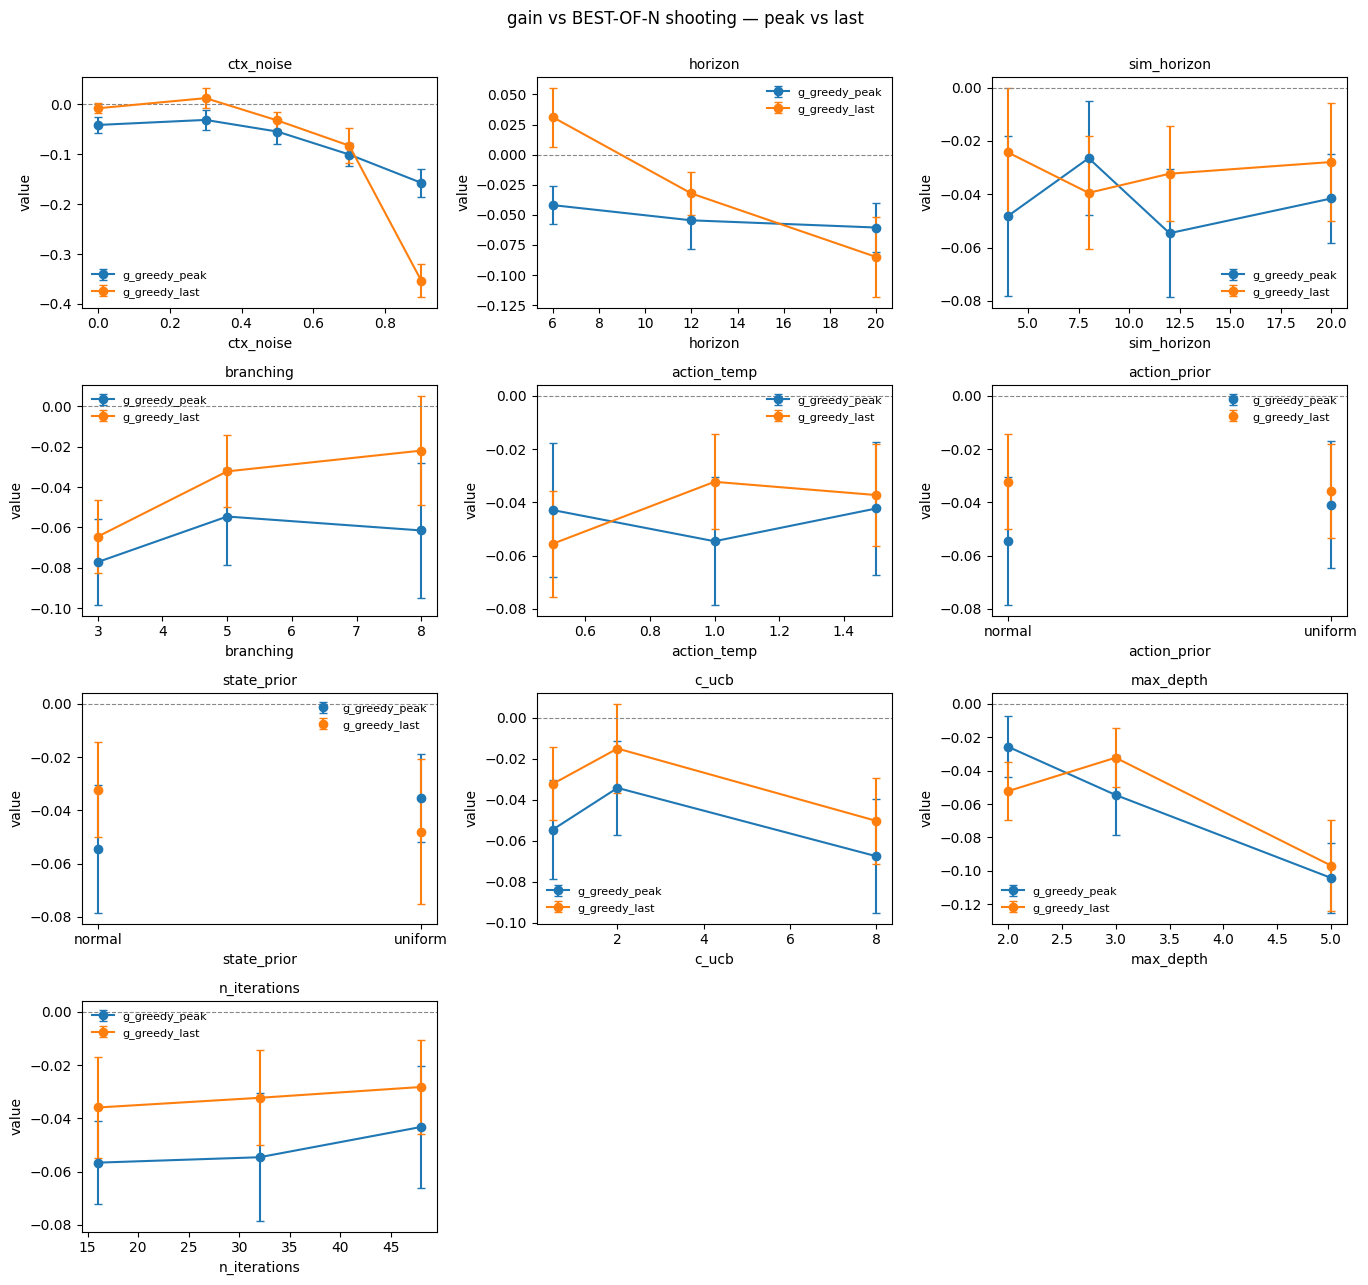

In [16]:
knob_grid([c for c in ["g_greedy_peak", "g_greedy_last"] if c in df.columns],
          title="gain vs BEST-OF-N shooting — peak vs last");

### 2e. Do the two objectives have the same predictors?

If the same tree signals top all four panels, the early-warning monitor is
objective-independent — which is what makes it usable online.

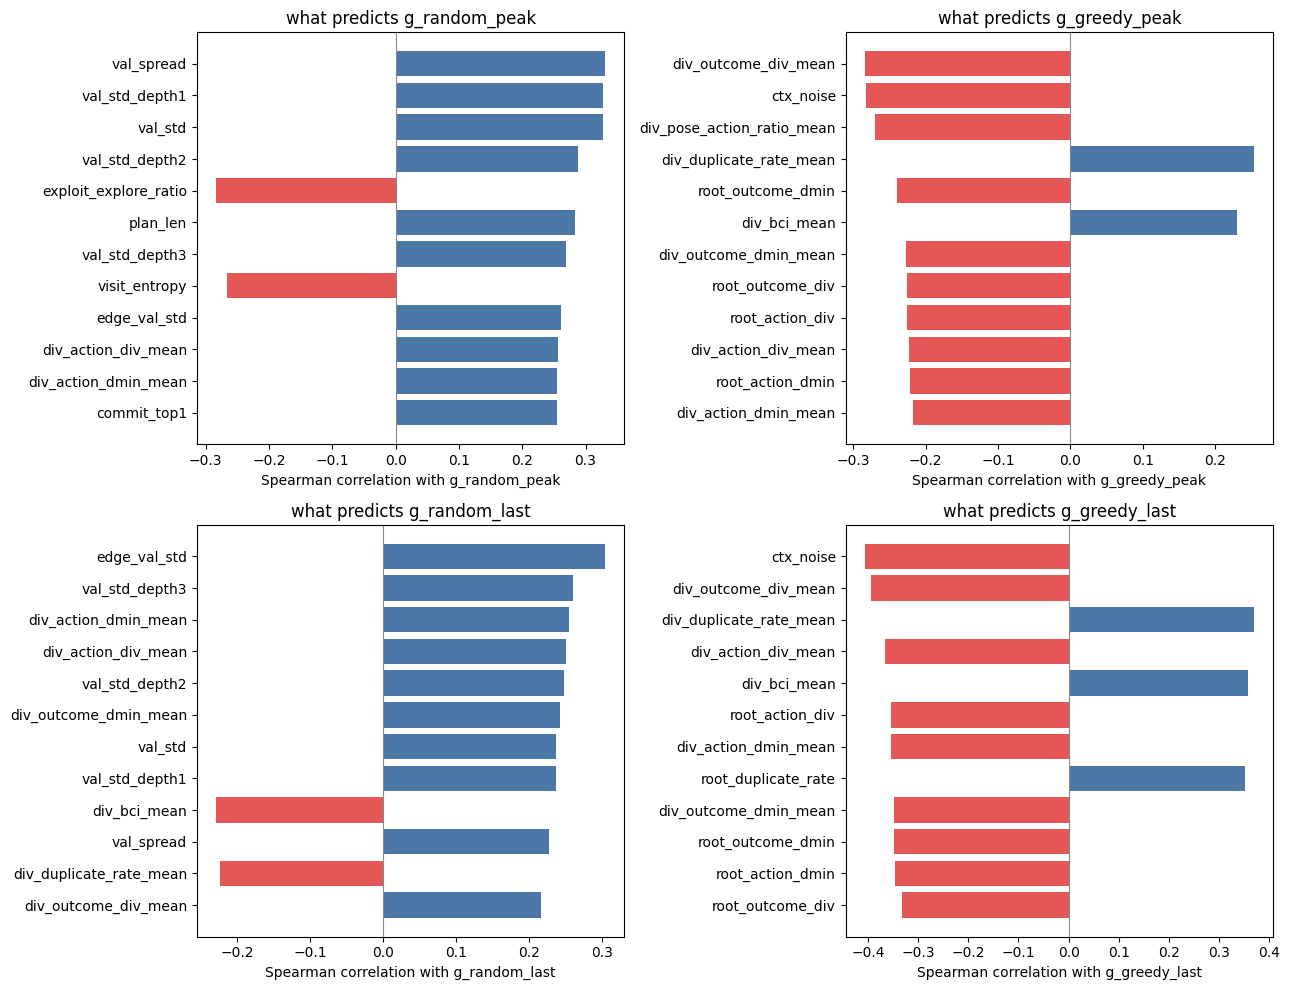

In [17]:
gains = [o for o in ["g_random_peak", "g_greedy_peak", "g_random_last", "g_greedy_last"]
         if o in df.columns]
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, o in zip(axes.ravel(), gains):
    charts.corr_bars(df, o, top=12, ax=ax)
for ax in axes.ravel()[len(gains):]:
    ax.axis("off")
fig.tight_layout()

### 2f. The two bars against each other

`g_greedy` is the harder test. Points above the diagonal = beat a single rollout but not
shooting; the lower-right quadrant is empty by construction (`greedy >= random` on the
same rollouts).

beat one rollout: 65.5%   |   beat best-of-N shooting: 23.8%


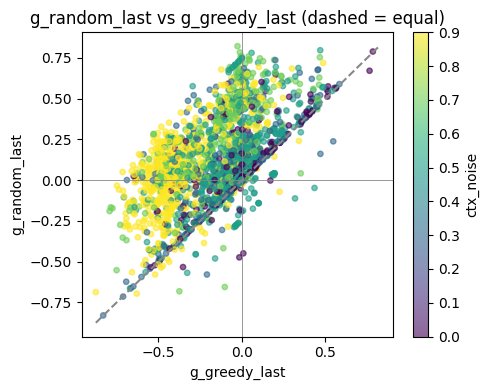

In [18]:
ax = charts.scatter(df, GAIN2, GAIN, color="ctx_noise")
lim = [min(df[GAIN2].min(), df[GAIN].min()), max(df[GAIN2].max(), df[GAIN].max())]
ax.plot(lim, lim, ls="--", color=charts.GREY)
ax.axhline(0, color=charts.GREY, lw=0.6); ax.axvline(0, color=charts.GREY, lw=0.6)
ax.set_title(f"{GAIN} vs {GAIN2} (dashed = equal)")
print(f"beat one rollout: {(df[GAIN] > 0).mean():.1%}   |   "
      f"beat best-of-N shooting: {(df[GAIN2] > 0).mean():.1%}")

## Part 3 — is a config good, or was it lucky?

The curated inits are **paired** across configs (same start states everywhere), and with
`n_seeds > 1` the sweep additionally re-plans the *same* start state under independent
planner RNG. Both let a config's edge be measured with the noise removed.

### 3a. Paired per-init deltas against `base`

Init-to-init variance is large and *shared* by every config, so differencing against `base`
on the same init is far more sensitive than comparing marginal means. `win_rate` is the
fraction of inits where the config beat `base`.

In [19]:
by_init = df.groupby(["config_tag", "init_id"])[OUT].mean()      # averages over replicates
base    = by_init.loc["base"]

def paired_delta(tag):
    d = (by_init.loc[tag] - base).dropna()
    return pd.Series({"n": len(d), "mean_delta": d.mean(), "sem": d.sem(),
                      "win_rate": (d > 0).mean()})

tags   = sorted(t for t in df.config_tag.unique() if t.startswith("ofat."))
paired = pd.DataFrame({t: paired_delta(t) for t in tags}).T.sort_values("mean_delta", ascending=False)
paired.round(4)

,n,mean_delta,sem,win_rate
ofat.ctx_noise=0.7,40.0,0.2018,0.0468,0.750
ofat.max_depth=5,40.0,0.1119,0.0388,0.700
ofat.horizon=20,40.0,0.1083,0.0473,0.650
ofat.c_ucb=2.0,40.0,0.0173,0.0142,0.550
ofat.branching=8,40.0,0.0103,0.0197,0.500
ofat.sim_horizon=4,40.0,0.0080,0.0201,0.525
ofat.sim_horizon=20,40.0,0.0044,0.0148,0.500
ofat.n_iterations=48,40.0,0.0041,0.0024,0.250
ofat.action_prior=uniform,40.0,0.0035,0.0072,0.450
ofat.action_temp=1.5,40.0,0.0034,0.0147,0.425


### 3b. Planner-seed replicates

`n_seeds=1` (the default) means `plan_seed == init_id` and seed noise is **not** separable
from init variance — re-run with `n_seeds=4` (see `study/README.md`) to size it. When
replicates exist, compare the within-(config, init) spread against the between-config
spread: if they are the same size, the ranking of configs is mostly seed luck.

In [20]:
reps = int(df.groupby(["config_id", "init_id"]).size().max())
if reps > 1:
    within  = df.groupby(["config_id", "init_id"])[OUT].std().mean()
    between = df.groupby("config_id")[OUT].mean().std()
    print(f"{reps} planner-RNG replicates per (config, init)")
    print(f"  within-(config,init) seed sd : {within:.4f}")
    print(f"  between-config sd            : {between:.4f}")
    print(f"  -> config signal / seed noise: {between / within:.2f}x")
else:
    print("n_seeds == 1 in this run: no planner-RNG replicates, seed noise is not separable.")

# always available: the init-to-init SEM per config — this is the error bar the curves show
per_cfg = df.groupby("config_id")[OUT].agg(["mean", "sem", "count"])
print("\nper-config SEM over inits:")
print(per_cfg["sem"].describe().round(4))

n_seeds == 1 in this run: no planner-RNG replicates, seed noise is not separable.

per-config SEM over inits:
count    72.0000
mean      0.0333
std       0.0108
min       0.0097
25%       0.0263
50%       0.0335
75%       0.0419
max       0.0574
Name: sem, dtype: float64


## Part 4 — comparing two runs

The sweeps are run once per *fixed* setting that isn't OFAT-able cheaply (the noise-prior
**shape**, the edge sampler). Concatenate them with a `run` label and every chart above
works on the union.

In [21]:
RUNS = {"normal": "mcts_sweep/run_normal", "uniform": "mcts_sweep/run_uniform"}
both = pd.concat([load_run(p).assign(run=name) for name, p in RUNS.items()],
                 ignore_index=True)
outs = [c for c in schema.OUTCOMES if c in both.columns]
both.groupby("run")[outs].mean().round(4)

,g_random_peak,g_greedy_peak,delta_over_root,tree_peak,g_random_last,g_greedy_last,tree_last
run,,,,,,,
normal,0.0091,-0.1007,0.3416,0.7013,0.0942,-0.1143,0.5681
uniform,0.0069,-0.1035,0.3415,0.7007,0.0935,-0.1163,0.5694


### 4a. Did the prior shape do anything?

Both runs also sweep `action_prior` / `state_prior` OFAT, so the effect can be read
*within* a run as well as across runs — two independent looks at the same question.

In [22]:
for k in ("action_prior", "state_prior"):
    if k in both.columns:
        print(both.groupby(["run", k], observed=True)[[GAIN, GAIN2, ABS]].mean().round(4), "\n")

                      g_random_last  g_greedy_last  tree_last
run     action_prior                                         
normal  normal               0.0866        -0.1071     0.5614
        uniform              0.1027        -0.1222     0.5757
uniform normal               0.0807        -0.1672     0.5409
        uniform              0.0978        -0.0993     0.5790 

                     g_random_last  g_greedy_last  tree_last
run     state_prior                                         
normal  normal              0.0938        -0.1240     0.5695
        uniform             0.0949        -0.0959     0.5655
uniform normal              0.0976        -0.1735     0.5625
        uniform             0.0910        -0.0820     0.5736 



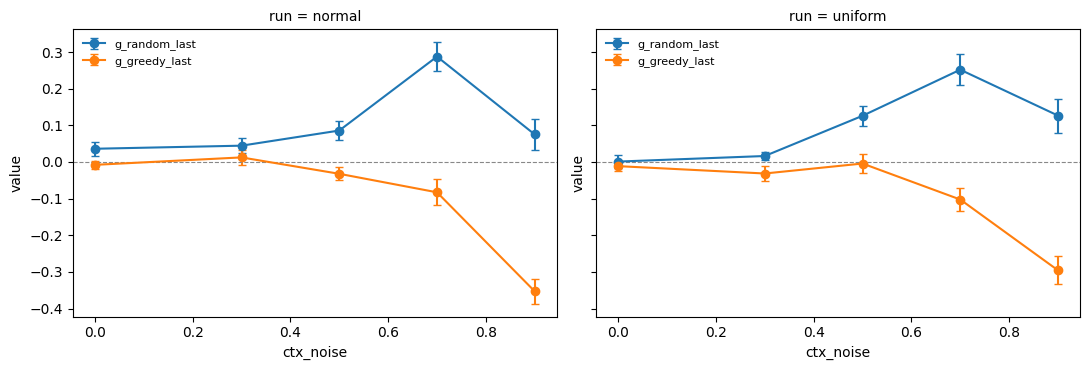

In [23]:
# side-by-side ctx_noise response, one panel per run (shared y so the panels are comparable)
fig, axes = plt.subplots(1, len(RUNS), figsize=(5.5 * len(RUNS), 3.8), sharey=True)
for ax, (name, d) in zip(np.atleast_1d(axes), both.groupby("run")):
    charts.response(charts.ofat(d, "ctx_noise"), "ctx_noise", [GAIN, GAIN2], ax=ax)
    ax.set_title(f"run = {name}", fontsize=10)
fig.tight_layout()

## Part 5 — what does the outcome cost?

`n_forward` counts denoiser *calls* and so misses `branching` and `sim_rollouts` entirely.
`optimize.plan_frames` counts denoiser **frames** from the config alone — which is the
budget the Bayesian optimiser constrains on, and the reason it can gate a candidate before
running it. Check both against measured wall clock here.

corr(plan_frames, plan_secs) = 0.954
corr(n_forward,   plan_secs) = 0.845


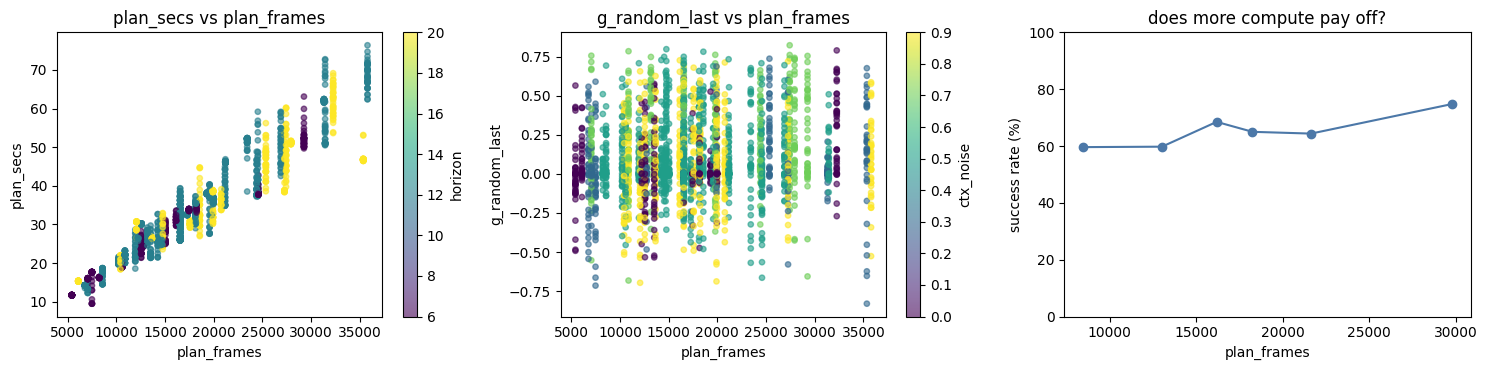

In [24]:
from dreamerv4uwm.planning.experiments.study.optimize import plan_frames

df["plan_frames"] = [plan_frames(r) for r in df.to_dict("records")]
print(f"corr(plan_frames, plan_secs) = {df.plan_frames.corr(df.plan_secs, method='spearman'):.3f}")
print(f"corr(n_forward,   plan_secs) = {df.n_forward.corr(df.plan_secs, method='spearman'):.3f}")

fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
charts.scatter(df, "plan_frames", "plan_secs", color="horizon", ax=ax[0])
charts.scatter(df, "plan_frames", OUT, color="ctx_noise", ax=ax[1])
x, rate = binned_rate("plan_frames")
ax[2].plot(x, 100 * rate, "o-", color=charts.BLUE)
ax[2].set(xlabel="plan_frames", ylabel="success rate (%)", title="does more compute pay off?")
ax[2].set_ylim(0, 100)
fig.tight_layout()

### 5a. Best outcome per unit of compute

One row per config: mean outcome vs the budget it spends. The upper-left frontier is what
an iso-compute optimiser is allowed to pick from.

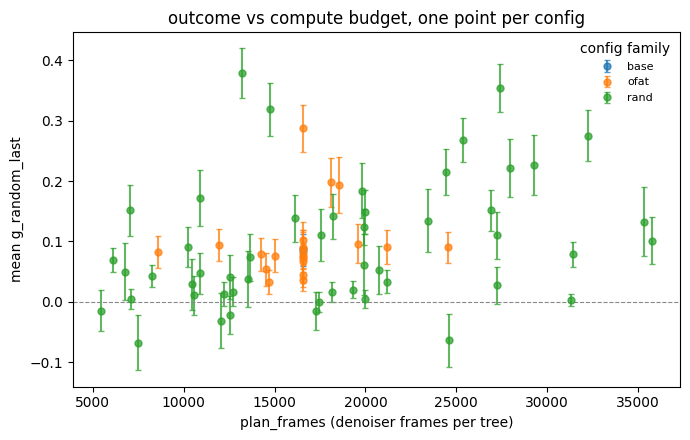

In [25]:
# NB: don't name an aggregated column `sem`/`mean`/`count` — attribute access on the
# result would resolve to the DataFrame *method* of that name instead of the column.
per = df.groupby(["config_id", "config_tag"], observed=True).agg(
    frames=("plan_frames", "mean"), outcome=(OUT, "mean"), err=(OUT, "sem")).reset_index()
fam = per.config_tag.str.extract(r"^(base|ofat|rand|bo)")[0].fillna("other")
fig, ax = plt.subplots(figsize=(7, 4.5))
for name, g in per.groupby(fam):
    ax.errorbar(g.frames, g.outcome, yerr=g.err, ls="none", marker="o", ms=5,
                capsize=2, alpha=0.75, label=name)
ax.axhline(0, color=charts.GREY, lw=0.8, ls="--")
ax.set(xlabel="plan_frames (denoiser frames per tree)", ylabel=f"mean {OUT}",
       title="outcome vs compute budget, one point per config")
ax.legend(fontsize=8, frameon=False, title="config family")
fig.tight_layout()

## Part 6 — tree properties as the subject

So far every chart put a **gain** on the y-axis. This part turns a *tree property*
(`visit_entropy`, `root_bci`, `val_std`, …) into the thing being studied. Two questions,
which look similar and are not:

| | question | y-axis | what it tells you |
|---|---|---|---|
| **6a–6b** | *which knobs shape the tree?* | the metric | mechanism — how a setting acts on the search |
| **6c–6e** | *does the tree's shape tell me planning worked?* | success, **conditioned on** the metric | whether the metric is a usable **monitor** |

Worth keeping straight, because a tree metric is **not** an outcome: `visit_entropy` near 1
means the search never committed, which is *evidence about* planning, not a measure of it.
Only the `g_*` gains say whether planning beat its baseline. Treating a metric as an outcome
would let a config "win" by producing confident-looking trees that plan badly — which is
exactly the failure mode 6e screens for.

Set `TREE_Y` to any metric; the whole part follows it.

In [26]:
TREE_Y = "visit_entropy"          # any column in METS: root_bci, val_std, exploit_explore_ratio, ...
SUCC   = f"success_{OUT}"         # the binary label: did this tree beat its matched baseline?

print(f"tree property : {TREE_Y}  -- {schema.DESCRIPTIONS.get(TREE_Y, '?')}")
print(f"link          : {schema.link_of(TREE_Y)}")
print(f"success label : {SUCC}  ({df[SUCC].mean():.1%} of {len(df)} trees)")
df[TREE_Y].describe().round(4)

tree property : visit_entropy  -- normalised entropy of root visit shares; 1 = uniform (undecided), 0 = committed
link          : L4_selection
success label : success_g_random_last  (65.5% of 2880 trees)


count    2880.0000
mean        0.7575
std         0.2786
min         0.1839
25%         0.4997
50%         0.9081
75%         0.9954
max         1.0000
Name: visit_entropy, dtype: float64

### 6a. Which knobs shape this tree property?

The same OFAT response curves as Part 1, with the metric on the y-axis. `charts.response`
draws the y=0 reference only when the curve straddles 0, so a bounded metric keeps its range.

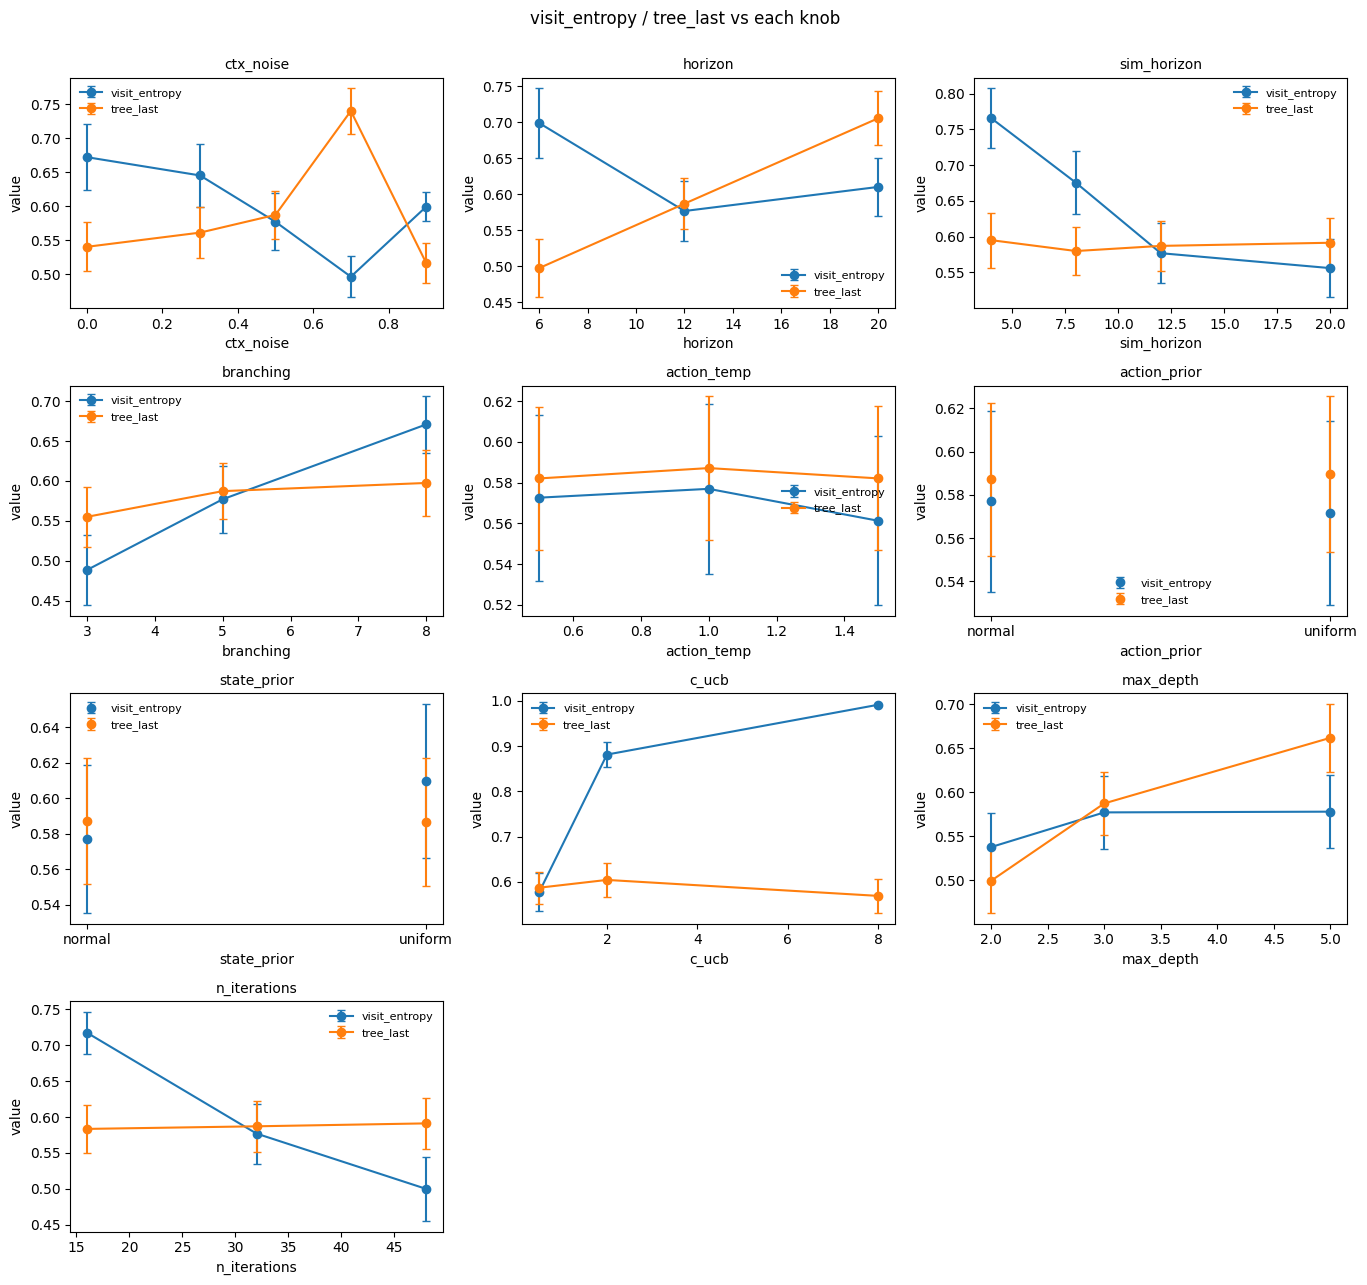

In [37]:
knob_grid(["visit_entropy", "tree_last"], title=f"visit_entropy / tree_last vs each knob");

### 6b. …for every tree property at once

Effect size = max−min of the metric's mean across a knob's OFAT settings, normalised **per
row** by that metric's own spread over the whole run — so rows in different units are
comparable. Read it as: *which knob is the main lever on which part of the search?*

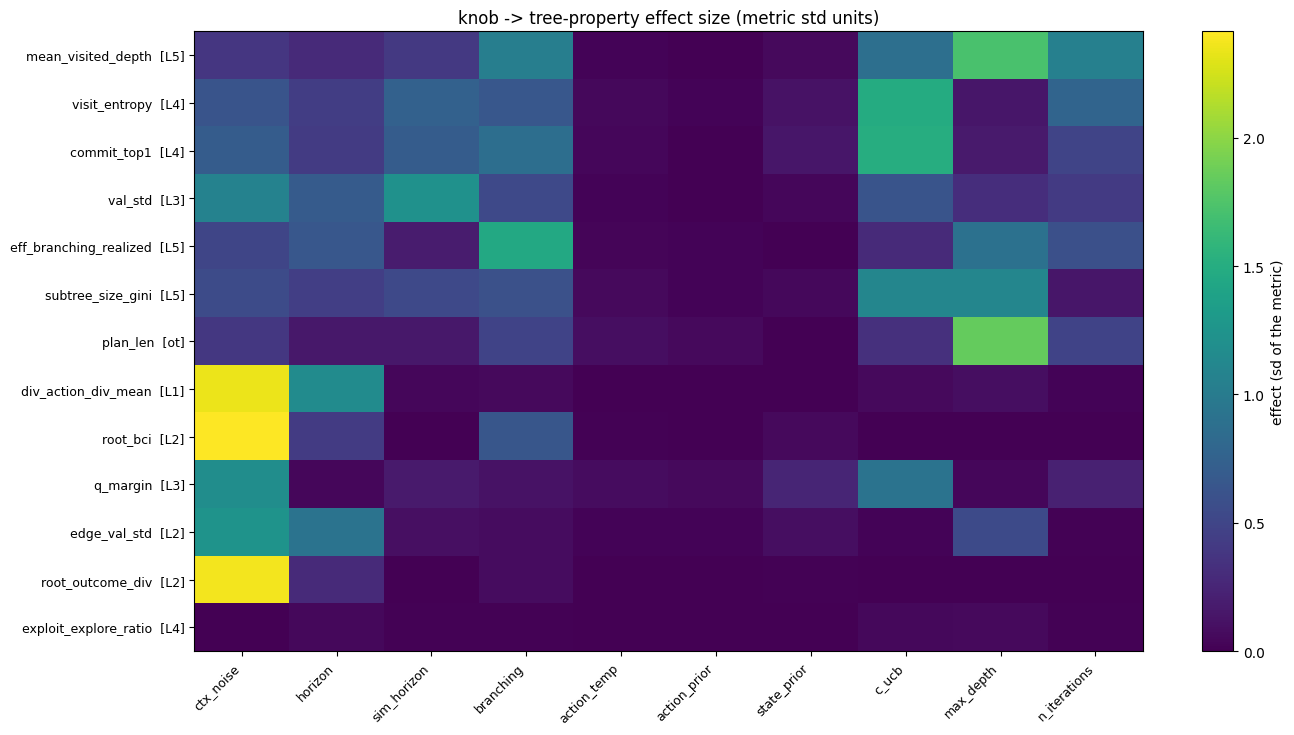

In [28]:
head = ["root_bci", "root_outcome_div", "div_action_div_mean", "edge_val_std",
        "val_std", "q_margin", "visit_entropy", "commit_top1", "exploit_explore_ratio",
        "mean_visited_depth", "subtree_size_gini", "eff_branching_realized", "plan_len"]
head = [m for m in head if m in df.columns]

E = pd.DataFrame({k: {m: effect_size(k, m) for m in head} for k in KNOBS})
E = E.div(df[head].std(), axis=0)                       # per-metric z-units
E = E.loc[E.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(1.1 * len(KNOBS) + 3, 0.42 * len(E) + 2))
im = ax.imshow(E.to_numpy(float), cmap="viridis", aspect="auto")
ax.set_xticks(range(E.shape[1]), E.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(E.shape[0]), [f"{m}  [{schema.link_of(m)[:2]}]" for m in E.index], fontsize=9)
ax.set_title("knob -> tree-property effect size (metric std units)")
fig.colorbar(im, ax=ax, label="effect (sd of the metric)")
fig.tight_layout()

### 6c. Conditioned on success: is the metric different in trees that planned well?

The distribution of `TREE_Y` split by the success label, then the ranked table over **all**
metrics. `auc` is P(metric higher in a success than in a failure) — 0.5 = no information,
>0.5 = higher means success, <0.5 = lower means success. `separation = |auc-0.5|*2` is the
threshold-free discriminability, and `cohen_d` the standardised mean gap.

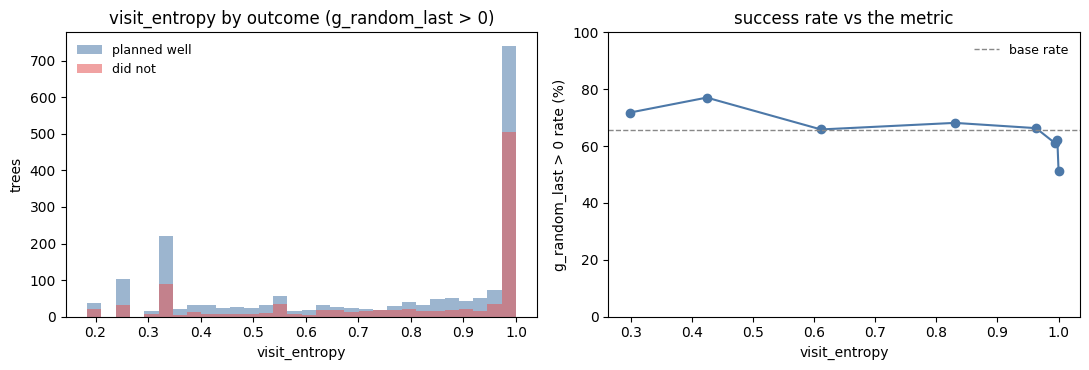

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for k, lab, col in [(1, "planned well", charts.BLUE), (0, "did not", charts.RED)]:
    ax[0].hist(df.loc[df[SUCC] == k, TREE_Y].dropna(), bins=30, alpha=0.55, color=col, label=lab)
ax[0].set(xlabel=TREE_Y, ylabel="trees", title=f"{TREE_Y} by outcome ({OUT} > 0)")
ax[0].legend(fontsize=9, frameon=False)

# success rate as a function of the metric — the monitor's calibration curve, in effect
x, rate = binned_rate(TREE_Y, q=8)
ax[1].plot(x, 100 * rate, "o-", color=charts.BLUE)
ax[1].axhline(100 * df[SUCC].mean(), color=charts.GREY, ls="--", lw=1, label="base rate")
ax[1].set(xlabel=TREE_Y, ylabel=f"{OUT} > 0 rate (%)", title="success rate vs the metric")
ax[1].set_ylim(0, 100); ax[1].legend(fontsize=9, frameon=False)
fig.tight_layout()

In [30]:
from scipy import stats as _st

def discriminability(succ=None, metrics=None, min_class=20):
    """Rank every metric by how well it separates successful from failed trees."""
    succ = succ or SUCC
    rows = []
    for m in (metrics or METS):
        d = df[[m, succ]].replace([np.inf, -np.inf], np.nan).dropna()
        a = d.loc[d[succ] == 1, m].to_numpy(float)     # planned well
        b = d.loc[d[succ] == 0, m].to_numpy(float)     # did not
        if min(len(a), len(b)) < min_class:
            continue
        auc = _st.mannwhitneyu(a, b, alternative="two-sided").statistic / (len(a) * len(b))
        sp = np.sqrt(((len(a) - 1) * a.var(ddof=1) + (len(b) - 1) * b.var(ddof=1))
                     / (len(a) + len(b) - 2))
        rows.append(dict(metric=m, link=schema.link_of(m), auc=auc,
                         separation=abs(auc - 0.5) * 2, cohen_d=(a.mean() - b.mean()) / (sp + 1e-12),
                         mean_success=a.mean(), mean_failure=b.mean(), n=len(d)))
    return (pd.DataFrame(rows).sort_values("separation", ascending=False)
            .reset_index(drop=True))

DISC = discriminability()
DISC.head(20).round(4)

,metric,link,auc,separation,cohen_d,mean_success,mean_failure,n
0,edge_val_std,L2_diversity,0.5997,0.1993,0.3560,0.1373,0.1108,2880
1,div_action_dmin_mean,L1_sampler,0.5911,0.1822,0.1296,0.1586,0.1358,2880
2,div_action_div_mean,L1_sampler,0.5907,0.1813,0.1886,0.2500,0.2090,2880
3,val_std,L3_value,0.5902,0.1804,0.3029,0.7911,0.5746,2880
4,val_std_depth1,L3_value,0.5902,0.1804,0.3029,0.7911,0.5746,2880
5,val_spread,L3_value,0.5878,0.1755,0.2988,1.2467,0.8850,2880
6,exploit_explore_ratio,L4_selection,0.4175,0.1650,-0.0967,97.8157,163.9959,2880
7,root_action_dmin,L1_sampler,0.5806,0.1613,0.0575,0.1306,0.1202,2880
8,div_outcome_dmin_mean,L2_diversity,0.5787,0.1573,0.0749,0.0648,0.0567,2880
9,val_std_depth3,L3_value,0.5780,0.1561,0.2313,0.7416,0.5799,1419


### 6d. Each metric alone as a detector (ROC)

If you had to stop a tree early on **one** number, how good would it be? Curves are oriented
so a metric that predicts failure is flipped (`auc < 0.5` → score negated), hence every AUC
here is ≥ 0.5 by construction; the sign lives in the label.

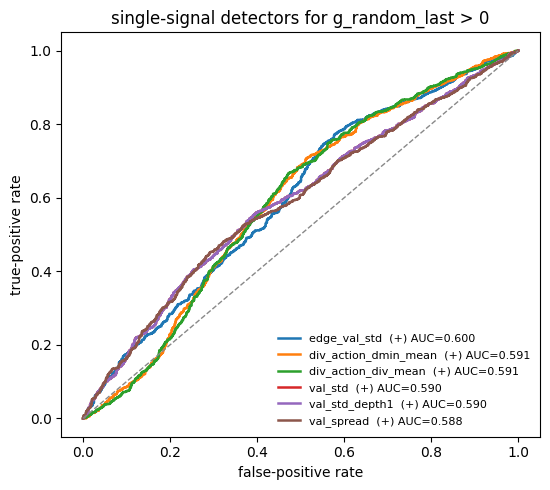

In [31]:
from sklearn.metrics import roc_curve

top = DISC.head(6)
fig, ax = plt.subplots(figsize=(5.6, 5))
d0 = df[[SUCC] + list(top.metric)].replace([np.inf, -np.inf], np.nan).dropna()
for _, r in top.iterrows():
    sign = 1.0 if r.auc >= 0.5 else -1.0                      # orient: higher score = success
    fpr, tpr, _ = roc_curve(d0[SUCC].to_numpy(int), sign * d0[r.metric].to_numpy(float))
    ax.plot(fpr, tpr, lw=1.8,
            label=f"{r.metric}  ({'+' if sign > 0 else '-'}) AUC={max(r.auc, 1 - r.auc):.3f}")
ax.plot([0, 1], [0, 1], ls="--", color=charts.GREY, lw=1)
ax.set(xlabel="false-positive rate", ylabel="true-positive rate",
       title=f"single-signal detectors for {OUT} > 0")
ax.legend(fontsize=8, frameon=False, loc="lower right")
fig.tight_layout()

### 6e. …but is it a *usable* monitor, or just a proxy for a knob you already set?

The catch: a metric can separate success beautifully and still be worthless online, because
it merely restates a knob you chose yourself (you already know your `horizon`). The test is
the **partial** rank correlation with success, controlling for every swept knob — what the
metric adds *within* a fixed configuration.

Points near the diagonal keep their signal after controlling; points that fall to the x-axis
were knob proxies all along.

,metric,link,spearman,partial_vs_knobs,retained
0,edge_val_std,L2_diversity,0.1641,0.1030,0.6273
2,div_action_div_mean,L1_sampler,0.1493,0.0956,0.6400
1,div_action_dmin_mean,L1_sampler,0.1500,0.0800,0.5332
5,val_spread,L3_value,0.1445,0.0757,0.5236
9,val_std_depth3,L3_value,0.1242,0.0755,0.6080
3,val_std,L3_value,0.1485,0.0749,0.5046
4,val_std_depth1,L3_value,0.1485,0.0749,0.5046
6,exploit_explore_ratio,L4_selection,-0.1359,-0.0630,0.4638
10,val_std_depth2,L3_value,0.1277,0.0628,0.4916
11,root_action_div,L1_sampler,0.1260,0.0620,0.4918


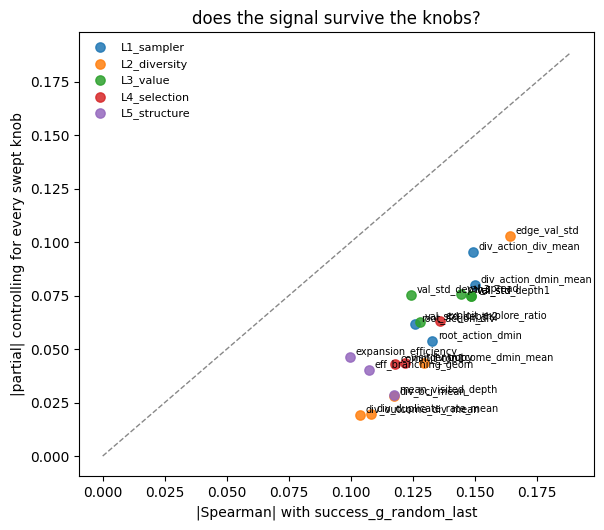

In [32]:
from dreamerv4uwm.planning.experiments.study.analysis.correlate import partial_spearman

rows = []
for m in DISC.metric.head(20):
    raw = df[[m, SUCC]].replace([np.inf, -np.inf], np.nan).dropna().corr(method="spearman").iloc[0, 1]
    rows.append(dict(metric=m, link=schema.link_of(m), spearman=raw,
                     partial_vs_knobs=partial_spearman(df, m, SUCC, KNOBS)))
PART = pd.DataFrame(rows).dropna()
PART["retained"] = (PART.partial_vs_knobs.abs() / PART.spearman.abs().replace(0, np.nan))

fig, ax = plt.subplots(figsize=(6.2, 5.4))
for link, g in PART.groupby("link"):
    ax.scatter(g.spearman.abs(), g.partial_vs_knobs.abs(), s=45, alpha=0.85, label=link)
    for _, r in g.iterrows():
        ax.annotate(r.metric, (abs(r.spearman), abs(r.partial_vs_knobs)),
                    fontsize=7, xytext=(4, 2), textcoords="offset points")
lim = [0, max(PART.spearman.abs().max(), PART.partial_vs_knobs.abs().max()) * 1.15]
ax.plot(lim, lim, ls="--", color=charts.GREY, lw=1)
ax.set(xlabel=f"|Spearman| with {SUCC}", ylabel="|partial| controlling for every swept knob",
       title="does the signal survive the knobs?")
ax.legend(fontsize=8, frameon=False)
fig.tight_layout()

PART.sort_values("partial_vs_knobs", key=abs, ascending=False).round(4)

## Part 7 — mechanism and correlation structure

### 7a. The causal chain at a glance — one headline metric per L1–L5 link vs the outcome
(L1 action diversity, L2 outcome diversity, L3 value spread, L4 exploit/explore, L5 subtree Gini.)

/home/mim-server/projects/felix/dreamerV4-UWM/dreamerv4uwm/planning/experiments/study/analysis/charts.py:123: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(d[x], d[y], c=(d[color] if color else BLUE), cmap="viridis", s=15, alpha=0.6)
/home/mim-server/projects/felix/dreamerV4-UWM/dreamerv4uwm/planning/experiments/study/analysis/charts.py:123: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(d[x], d[y], c=(d[color] if color else BLUE), cmap="viridis", s=15, alpha=0.6)
/home/mim-server/projects/felix/dreamerV4-UWM/dreamerv4uwm/planning/experiments/study/analysis/charts.py:123: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(d[x], d[y], c=(d[color] if color else BLUE), cmap="viridis", s=15, alpha=0.6)
/home/mim-server/projects/felix/dreamerV4-UWM/dreamerv4uwm/planning/experiments/study/analysis/charts.py:123: Us

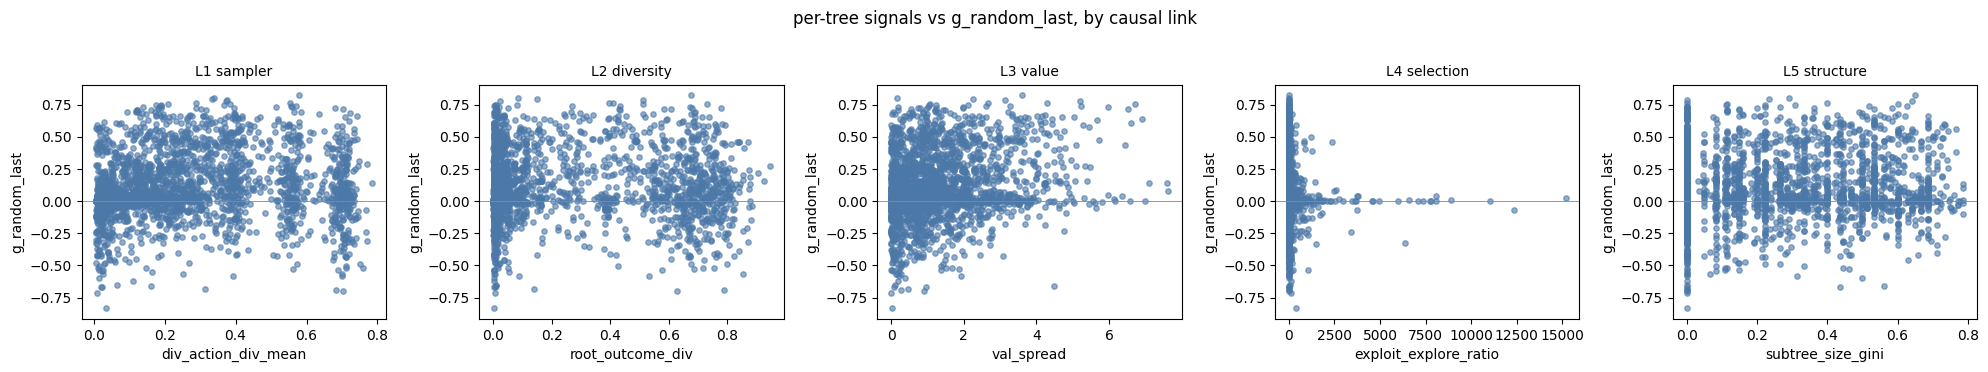

In [33]:
chain = [("div_action_div_mean", "L1 sampler"), ("root_outcome_div", "L2 diversity"),
         ("val_spread", "L3 value"), ("exploit_explore_ratio", "L4 selection"),
         ("subtree_size_gini", "L5 structure")]
chain = [(m, lab) for m, lab in chain if m in df.columns]
fig, axes = plt.subplots(1, len(chain), figsize=(4 * len(chain), 3.6))
for ax, (m, lab) in zip(np.atleast_1d(axes), chain):
    charts.scatter(df, m, OUT, ax=ax)
    ax.axhline(0, color=charts.GREY, lw=0.6)
    ax.set_title(lab, fontsize=10)
fig.suptitle(f"per-tree signals vs {OUT}, by causal link", y=1.02)
fig.tight_layout()

### 6b. Correlation structure — both objectives' gains + one metric per link

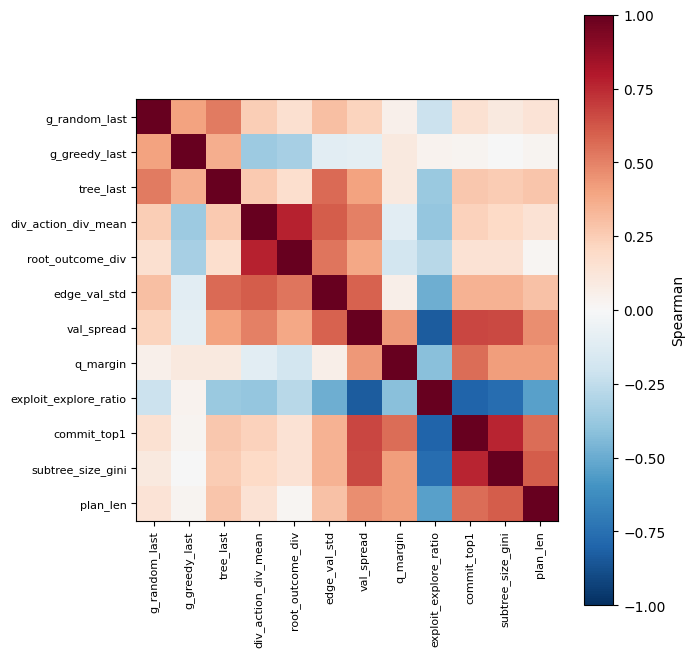

In [34]:
hm = [GAIN, GAIN2, ABS, "div_action_div_mean", "root_outcome_div", "edge_val_std",
      "val_spread", "q_margin", "exploit_explore_ratio", "commit_top1",
      "subtree_size_gini", "plan_len"]
charts.heatmap(df, [c for c in dict.fromkeys(hm) if c in df.columns]);

### 7c. Diversity -> reliability: success rate vs branch-collapse (root)
Low `root_bci` (edges stay distinct) should mean planning helps more often.

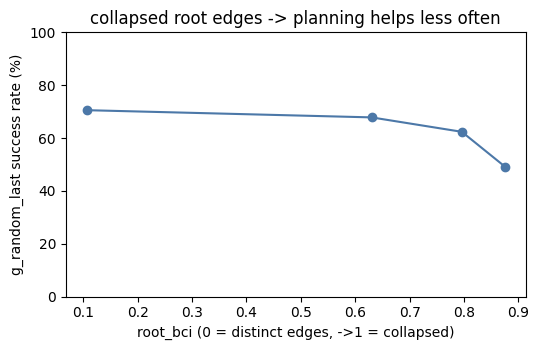

In [35]:
x, rate = binned_rate("root_bci")
fig, ax = plt.subplots(figsize=(5.5, 3.6))
ax.plot(x, 100 * rate, "o-", color=charts.BLUE)
ax.set(xlabel="root_bci (0 = distinct edges, ->1 = collapsed)",
       ylabel=f"{OUT} success rate (%)",
       title="collapsed root edges -> planning helps less often")
ax.set_ylim(0, 100)
fig.tight_layout()

## Reference — what every column means

In [36]:
with pd.option_context("display.max_rows", None, "display.max_colwidth", 100):
    display(schema.data_dictionary(df))

,column,kind,link,dtype,description
0,config_id,meta,,int64,index of the config in the sweep (0..n_configs-1)
1,config_tag,meta,,str,human tag of the config: 'base' or 'ofat.<knob>=<value>'
2,descriptor_kind,meta,,str,diversity descriptor: pose (axis theta) | heading (up/down-resolved)
3,dtype,meta,,str,autocast dtype used for the rollouts (bfloat16)
4,init_id,meta,,int64,index of the curated initial state (decision point)
5,plan_secs,meta,,float64,wall-clock seconds spent building this tree
6,plan_seed,meta,,int64,RNG seed of the planner for this tree
7,reward_kind,meta,,str,reward that scored this tree: center | straight (axis) | angle (upright)
8,t0,meta,,int64,frame offset inside that window where the Tc-frame context starts
9,window_idx,meta,,int64,dataset index of the demo window the initial context came from
